In [18]:
# Imports
import pandas as pd
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, root_mean_squared_error, r2_score
from tqdm import tqdm
import matplotlib.pyplot as plt

In [19]:
# Load Data
train_df = pd.read_csv(r'./Data/train.csv')
test_df = pd.read_csv(r'./Data/test.csv')

In [20]:
train_df.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257587,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [21]:
# Count of missing values per column
train_df.isna().sum().to_frame('missing_count')


,missing_count
id,0
RhythmScore,0
AudioLoudness,0
VocalContent,0
AcousticQuality,0
InstrumentalScore,0
LivePerformanceLikelihood,0
MoodScore,0
TrackDurationMs,0
Energy,0


<Axes: xlabel='RhythmScore', ylabel='Count'>

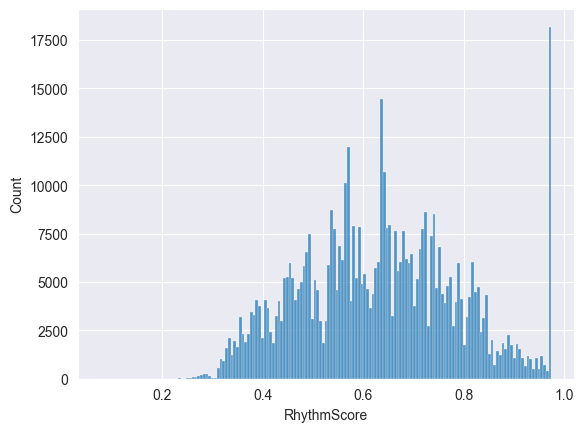

In [22]:
sns.histplot(train_df['RhythmScore'])

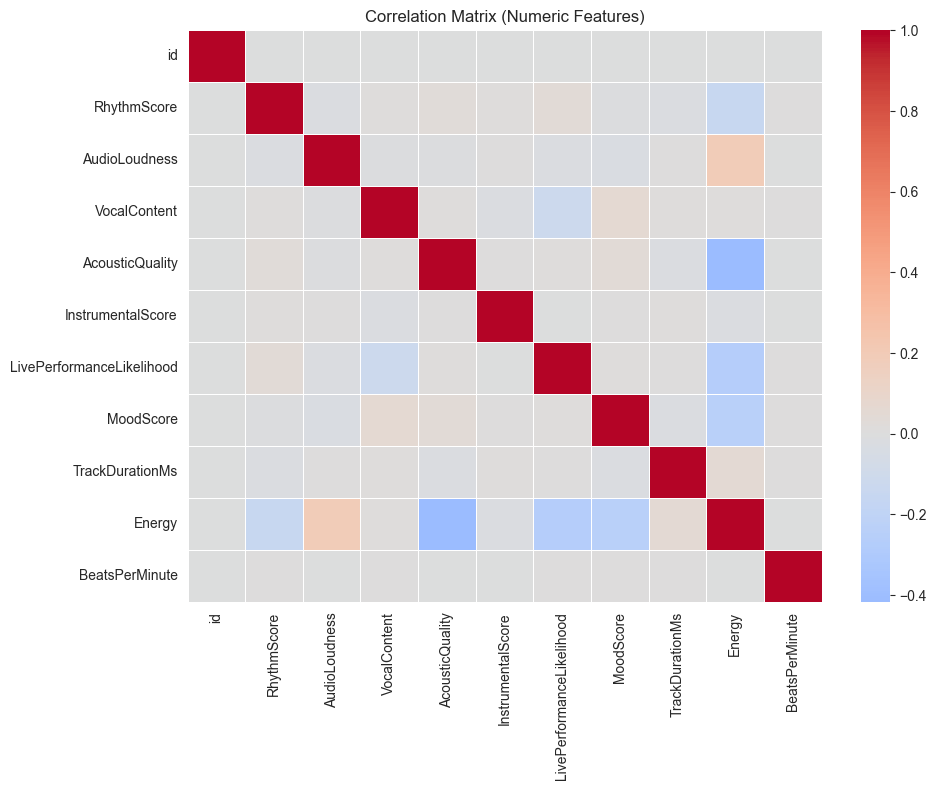

In [23]:
# Correlation matrix for numeric columns in train_df
numeric_df = train_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()


In [24]:
# Train/validation split
target_col = 'BeatsPerMinute'
feature_cols = [c for c in train_df.columns if c not in ['id', target_col]]

X = train_df[feature_cols]
y = train_df[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}, X_valid shape: {X_valid.shape}")


X_train shape: (419331, 9), X_valid shape: (104833, 9)


In [25]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=17,
    n_jobs=-1
)

In [26]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
valid_preds = xgb_model.predict(X_valid)

In [28]:
rmse = root_mean_squared_error(y_valid, valid_preds)
r2 = r2_score(y_valid, valid_preds)
print(f"RMSE: {rmse:.4f} | R2: {r2:.4f}")


RMSE: 26.4403 | R2: 0.0004


In [29]:
train_preds = xgb_model.predict(X_train)
rmse = root_mean_squared_error(y_train, train_preds)
r2 = r2_score(y_train, train_preds)
print(f"RMSE: {rmse:.4f} | R2: {r2:.4f}")

RMSE: 26.2589 | R2: 0.0162


In [30]:
test_df_clean = test_df.drop(columns=['id'])
test_preds = xgb_model.predict(test_df_clean)
submission = pd.DataFrame({
    "id": test_df.id,
    "BeatsPerMinute": test_preds
})
submission.to_csv("submission.csv", index=False)


In [ ]:
# Giant Grid Search for LightGBM parameters, save the best model, print best params, and create a submission
from sklearn.model_selection import GridSearchCV
import joblib
from lightgbm import LGBMRegressor

# Base model (LightGBM)
lgb_base = LGBMRegressor(
    objective="regression",
    random_state=17,
    n_jobs=-1,
)

# A parameter grid (adjust as needed for your compute budget)
# Note: LightGBM uses 'subsample' (bagging fraction) and 'colsample_bytree' (feature fraction).
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_alpha": [0.0, 0.1, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
}

# Count combinations for transparency
try:
    total_combos = int(np.prod([len(v) for v in param_grid.values()]))
except Exception:
    total_combos = None

grid = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE (negated because higher is better in sklearn)
    cv=3,
    n_jobs=-1,
    verbose=3,
    return_train_score=False,
)

print("Starting Grid Search (LightGBM)..." + (f" Total combinations: {total_combos}" if total_combos is not None else ""))

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = -grid.best_score_

print("Best CV RMSE:", round(best_cv_rmse, 6))
print("Best Params:", best_params)

# Save the best model and params
joblib.dump(best_model, "best_lgbm_model.pkl")
pd.Series(best_params).to_csv("best_lgbm_params.csv")

# Evaluate on the holdout validation set available in this notebook
valid_preds_best = best_model.predict(X_valid)
val_rmse = root_mean_squared_error(y_valid, valid_preds_best)
val_r2 = r2_score(y_valid, valid_preds_best)
print(f"Validation RMSE (holdout): {val_rmse:.6f} | R2: {val_r2:.6f}")

# Predict on test and save to a submission file
# Reuse previously created test_df_clean (test_df with 'id' dropped)
test_preds_best = best_model.predict(test_df_clean)
submission_best = pd.DataFrame({
    "id": test_df.id,
    "BeatsPerMinute": test_preds_best
})
submission_best.to_csv("submission_best_lgbm.csv", index=False)
print("Saved: best_lgbm_model.pkl, best_lgbm_params.csv, submission_best_lgbm.csv")


Starting Grid Search (LightGBM)... Total combinations: 1944
Fitting 3 folds for each of 1944 candidates, totalling 5832 fits
